# Machine Learning Final Project : Nutrient Regression
**Logan Dawes** - CS4783

The goal of this project is to develop a machine learning model for both classification and prediction tasks. The model will be designed to automatically infer missing ingredient lists and nutrient information for a given food item. This enables it to perform ingredient classification as well as nutrient estimation

### Import Libraries

In [3]:
%reset -f

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import gc
import concurrent
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

In [5]:
# Utility function to build and compile LSTM model
def make_lstm_model(window_size, feature_count, output_count, units_1, units_2, dropout_1, dropout_2, l2_reg, learning_rate):
    model = Sequential()
    model.add(Input(shape=(window_size, feature_count)))
    model.add(LSTM(units=units_1, return_sequences=True))
    model.add(Dropout(dropout_1))
    model.add(BatchNormalization())
    model.add(LSTM(units=units_2))
    model.add(Dropout(dropout_2))
    model.add(BatchNormalization())
    model.add(Dense(output_count, kernel_regularizer=l2_reg, activation='softplus'))
    adam_opt = Adam(learning_rate=learning_rate)
    model.compile(optimizer=adam_opt, loss='mean_squared_error')
    return model

### Load Cleaned Dataset

In [ ]:
# Load datatypes for final_food_data
with open('final_food_data_dtypes.json', 'r') as f:
    final_food_data_dtypes = json.load(f)

# Load processed dataset
food_data = pd.read_csv('final_food_data.csv', dtype=final_food_data_dtypes)

# Select all nutrient amount columns (exclude logs and package weight)
nutrient_candidates = [col for col in food_data.columns if 'amount' in col and not col.endswith('_log') and not col == 'package_weight_amount']
print('Zero percentage for each nutrient candidate:')
nutrient_cols = []
for col in nutrient_candidates:
    zero_pct = (food_data[col] == 0).mean() * 100
    print(f'{col}: {zero_pct:.2f}% zero')
    if zero_pct <= 90:
        nutrient_cols.append(col)
print(f'Total nutrient candidates: {len(nutrient_candidates)}')
print(f'Nutrient columns ({len(nutrient_cols)}): {nutrient_cols}')

# Select all one-hot ingredient columns
ingredient_oh_cols = [col for col in food_data.columns if col.startswith('ingredient_oh_')]
print(f'Ingredient one-hot columns: {ingredient_oh_cols[:10]} ... total: {len(ingredient_oh_cols)}')

# Drop ingredient one-hot columns with >90% zeros
filtered_ingredient_oh_cols = [
    col for col in ingredient_oh_cols
    if (food_data[col] == 0).mean() <= 0.9
]
failed_ingredient_oh_cols = set(ingredient_oh_cols) - set(filtered_ingredient_oh_cols)
print(f'Filtered ingredient one-hot columns: {filtered_ingredient_oh_cols[:10]} ... total: {len(filtered_ingredient_oh_cols)}')

Zero percentage for each nutrient candidate:
Acetic acid amount: 100.00% zero
Alanine amount: 99.98% zero
Alcohol, ethyl amount: 100.00% zero
Arginine amount: 99.98% zero
Ash amount: 99.82% zero
Aspartic acid amount: 99.98% zero
Beta-glucans amount: 100.00% zero
Biotin amount: 99.80% zero
Caffeine amount: 99.96% zero
Calcium, Ca amount: 44.51% zero
Carbohydrate, by difference amount: 15.33% zero
Carbohydrate, other amount: 99.77% zero
Carotene, beta amount: 100.00% zero
Chlorine, Cl amount: 99.92% zero
Cholesterol amount: 66.02% zero
Choline, from phosphotidyl choline amount: 100.00% zero
Choline, total amount: 99.94% zero
Chromium, Cr amount: 99.90% zero
Copper, Cu amount: 98.95% zero
Cysteine amount: 99.99% zero
Cystine amount: 99.99% zero
Energy amount: 11.22% zero
Epigallocatechin-3-gallate amount: 100.00% zero
Fatty acids, total monounsaturated amount: 91.02% zero
Fatty acids, total polyunsaturated amount: 91.20% zero
Fatty acids, total saturated amount: 46.82% zero
Fatty acids, t

In [ ]:
# Prepare input features (exclude nutrient columns and failed ingredient one-hot columns)
exclude_cols = set(nutrient_cols)
exclude_cols.update(failed_ingredient_oh_cols)
feature_cols = [col for col in food_data.columns if col not in exclude_cols]

# Memory cleanup after data loading
def memory_cleanup(data):
    for var in data:
        if var in locals():
            del globals()[var]
    gc.collect()
    
memory_cleanup(['final_food_data_dtypes', 'f', 'exclude_cols'])

## Step 1: Train/Test Split

In [8]:
# Batch generator for memory-efficient training
def batch_generator(data, feature_cols, nutrient_cols, window_size=3, batch_size=128):
    num_rows = len(data)
    while True:
        for start in range(window_size, num_rows, batch_size):
            end = min(start + batch_size, num_rows)
            X_batch = []
            y_batch = []
            for i in range(start, end):
                X_window = data.iloc[i-window_size:i][feature_cols].values
                y_row = data.iloc[i][nutrient_cols].values
                X_batch.append(X_window)
                y_batch.append(y_row)
            yield np.array(X_batch), np.array(y_batch)

In [9]:
# Set window size and batch size
window_size = 3
batch_size = 128

# Calculate split index for train/test
num_rows = len(food_data)
split_idx = int((num_rows - window_size) * 0.8)
print(f'[Split] Total rows: {num_rows}, Train rows: {split_idx + window_size}, Test rows: {num_rows - split_idx}')

# Define train and test generators
train_gen = batch_generator(
    food_data.iloc[:split_idx + window_size],
    feature_cols,
    nutrient_cols,
    window_size=window_size,
    batch_size=batch_size
)
test_gen = batch_generator(
    food_data.iloc[split_idx:],
    feature_cols,
    nutrient_cols,
    window_size=window_size,
    batch_size=batch_size
)

# Calculate steps per epoch
train_steps = (split_idx) // batch_size
test_steps = (num_rows - window_size - split_idx) // batch_size
print(f'[Steps] Train steps per epoch: {train_steps}, Test steps: {test_steps}')

[Split] Total rows: 1977398, Train rows: 1581919, Test rows: 395482
[Steps] Train steps per epoch: 12358, Test steps: 3089


## Step 2: Build the Model

In [10]:
# Build the LSTM model for multi-output regression with L2 regularization using best hyperparameters from KerasTuner
l2_reg = regularizers.l2(0.001)
units_1 = 32
units_2 = 96
dropout_1 = 0.2
dropout_2 = 0.2
learning_rate = 0.001
print(f'[Model] Building LSTM model with input shape ({window_size}, {len(feature_cols)}) and output size {len(nutrient_cols)}')
model = make_lstm_model(window_size, len(feature_cols), len(nutrient_cols), units_1, units_2, dropout_1, dropout_2, l2_reg, learning_rate)

[Model] Building LSTM model with input shape (3, 720) and output size 15


## Step 3: Train the Model

In [11]:
# Fit the model using the batch generator
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print(f'[Training] Starting model.fit for up to 20 epochs, batch size {batch_size}, train steps {train_steps}, validation steps {test_steps}')
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=20,
    validation_data=test_gen,
    validation_steps=test_steps,
    callbacks=[early_stop]
)

[Training] Starting model.fit for up to 20 epochs, batch size 128, train steps 12358, validation steps 3089
Epoch 1/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1845s 149ms/step - loss: 295.3945 - val_loss: 326.5491
Epoch 2/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1876s 152ms/step - loss: 293.6396 - val_loss: 323.3747
Epoch 3/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1918s 155ms/step - loss: 293.7861 - val_loss: 327.8302
Epoch 4/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1930s 156ms/step - loss: 293.8117 - val_loss: 327.4639
Epoch 5/20
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1951s 158ms/step - loss: 293.8519 - val_loss: 335.0476


In [12]:
# Collect predictions and true values from test generator for RMSE calculation
y_true = []
y_pred = []
for batch_num in range(test_steps):
    X_batch, y_batch = next(test_gen)
    preds = model.predict(X_batch)
    y_true.append(y_batch)
    y_pred.append(preds)
    percent_complete = int(100 * (batch_num + 1) / test_steps)
    print(f'\n[Prediction] {percent_complete}%', end='\r')
    gc.collect()
y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━

In [13]:
# Evaluate RMSE for each nutrient
rmses = [np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])) for i in range(len(nutrient_cols))]
for col, rmse in zip(nutrient_cols, rmses):
    print(f'RMSE for {col}: {rmse:.4f}')

RMSE for Calcium, Ca amount: 5.2609
RMSE for Carbohydrate, by difference amount: 52.1980
RMSE for Cholesterol amount: 0.2126
RMSE for Energy amount: 0.4907
RMSE for Fatty acids, total saturated amount: 8.8432
RMSE for Fiber, total dietary amount: 9.6193
RMSE for Iron, Fe amount: 0.2673
RMSE for Potassium, K amount: 0.2915
RMSE for Protein amount: 20.4527
RMSE for Sodium, Na amount: 0.2737
RMSE for Sugars, added amount: 17.7311
RMSE for Total Sugars amount: 27.1302
RMSE for Total lipid (fat) amount: 21.3875
RMSE for Vitamin A, IU amount: 0.1597
RMSE for Vitamin C, total ascorbic acid amount: 0.1545


In [14]:
# Calculate R squared and residuals for each nutrient
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else 0.0

r2s = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(len(nutrient_cols))]
residuals = y_true - y_pred
for col, r2 in zip(nutrient_cols, r2s):
    print(f'R squared for {col}: {r2:.4f}')
print('Residuals shape:', residuals.shape)

R squared for Calcium, Ca amount: -0.0002
R squared for Carbohydrate, by difference amount: -0.0136
R squared for Cholesterol amount: -0.0022
R squared for Energy amount: -0.0047
R squared for Fatty acids, total saturated amount: -0.0142
R squared for Fiber, total dietary amount: -0.0065
R squared for Iron, Fe amount: -0.0021
R squared for Potassium, K amount: -0.0686
R squared for Protein amount: -0.0033
R squared for Sodium, Na amount: -0.0010
R squared for Sugars, added amount: -0.0035
R squared for Total Sugars amount: -0.0097
R squared for Total lipid (fat) amount: -0.0121
R squared for Vitamin A, IU amount: -0.0299
R squared for Vitamin C, total ascorbic acid amount: -0.0075
Residuals shape: (395351, 15)


## Step 4: Evaluate the Model

In [15]:
# Print summary statistics for RMSEs, R squared, and residuals
print('RMSE Summary:')
print(f'Mean RMSE: {np.mean(rmses):.4f}')
print(f'Median RMSE: {np.median(rmses):.4f}')
print(f'Min RMSE: {np.min(rmses):.4f}')
print(f'Max RMSE: {np.max(rmses):.4f}\n')

print('R squared Summary:')
print(f'Mean R^2: {np.mean(r2s):.4f}')
print(f'Median R^2: {np.median(r2s):.4f}')
print(f'Min R^2: {np.min(r2s):.4f}')
print(f'Max R^2: {np.max(r2s):.4f}\n')

print('Residuals Summary:')
print(f'Mean residual: {np.mean(residuals):.4f}')
print(f'Median residual: {np.median(residuals):.4f}')
print(f'Min residual: {np.min(residuals):.4f}')
print(f'Max residual: {np.max(residuals):.4f}')

RMSE Summary:
Mean RMSE: 10.9649
Median RMSE: 5.2609
Min RMSE: 0.1545
Max RMSE: 52.1980

R squared Summary:
Mean R^2: -0.0119
Median R^2: -0.0065
Min R^2: -0.0686
Max R^2: -0.0002

Residuals Summary:
Mean residual: 0.2490


Median residual: -0.1194
Min residual: -257.3562
Max residual: 5306.2364


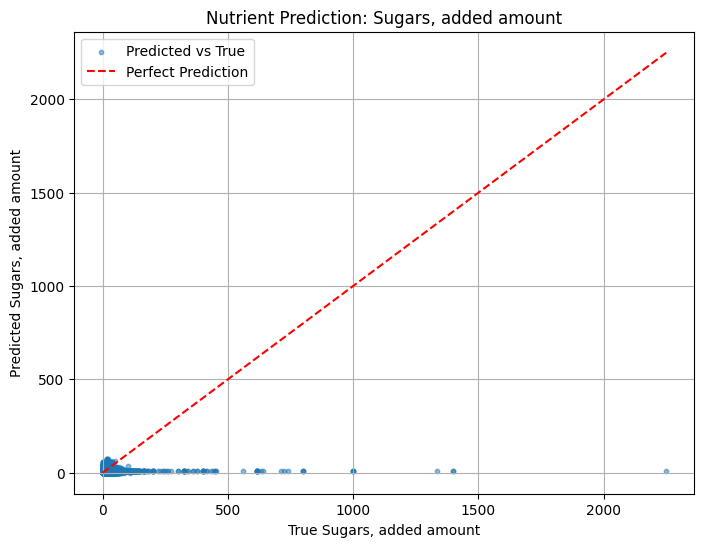

In [16]:
# Visualize nutrient prediction: scatter plot with prediction line
sodium_candidates = [col for col in nutrient_cols if 'sugar' in col.lower()]
if sodium_candidates:
    sodium_col = sodium_candidates[0]
    nutrient_idx = nutrient_cols.index(sodium_col)
else:
    nutrient_idx = 0  # fallback to first nutrient
nutrient_name = nutrient_cols[nutrient_idx]

plt.figure(figsize=(8, 6))
plt.scatter(y_true[:, nutrient_idx], y_pred[:, nutrient_idx], alpha=0.5, label='Predicted vs True', s=10)
# Plot prediction line (y = x)
min_val = min(np.min(y_true[:, nutrient_idx]), np.min(y_pred[:, nutrient_idx]))
max_val = max(np.max(y_true[:, nutrient_idx]), np.max(y_pred[:, nutrient_idx]))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('True ' + nutrient_name)
plt.ylabel('Predicted ' + nutrient_name)
plt.title(f'Nutrient Prediction: {nutrient_name}')
plt.legend()
plt.grid(True)
plt.show()